In [9]:
import matplotlib.pyplot as plt

import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from lib.cea_lib.signal1D import*
from lib.cea_lib.general import*
from lib.cea_lib.data_loader import*
from lib.cea_lib.output import*
from lib.cea_lib.signal2D import*
from lib.cea_lib.physic import*
from lib.cea_lib.data_exporter import*

In [10]:
import matplotlib.pyplot as plt

REPORT_PLOT_STYLE = {
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
}
plt.rcParams.update(REPORT_PLOT_STYLE)


# Visualisation

In [11]:
data, labels = load_RTCEA("../data/RTCEA_bimode.hdf5")

In [12]:
atwood = create_atwood_dic(labels)
idxs = atwood[0.3]
sim = data[idxs,:,:] 
time = labels[idxs,1]   

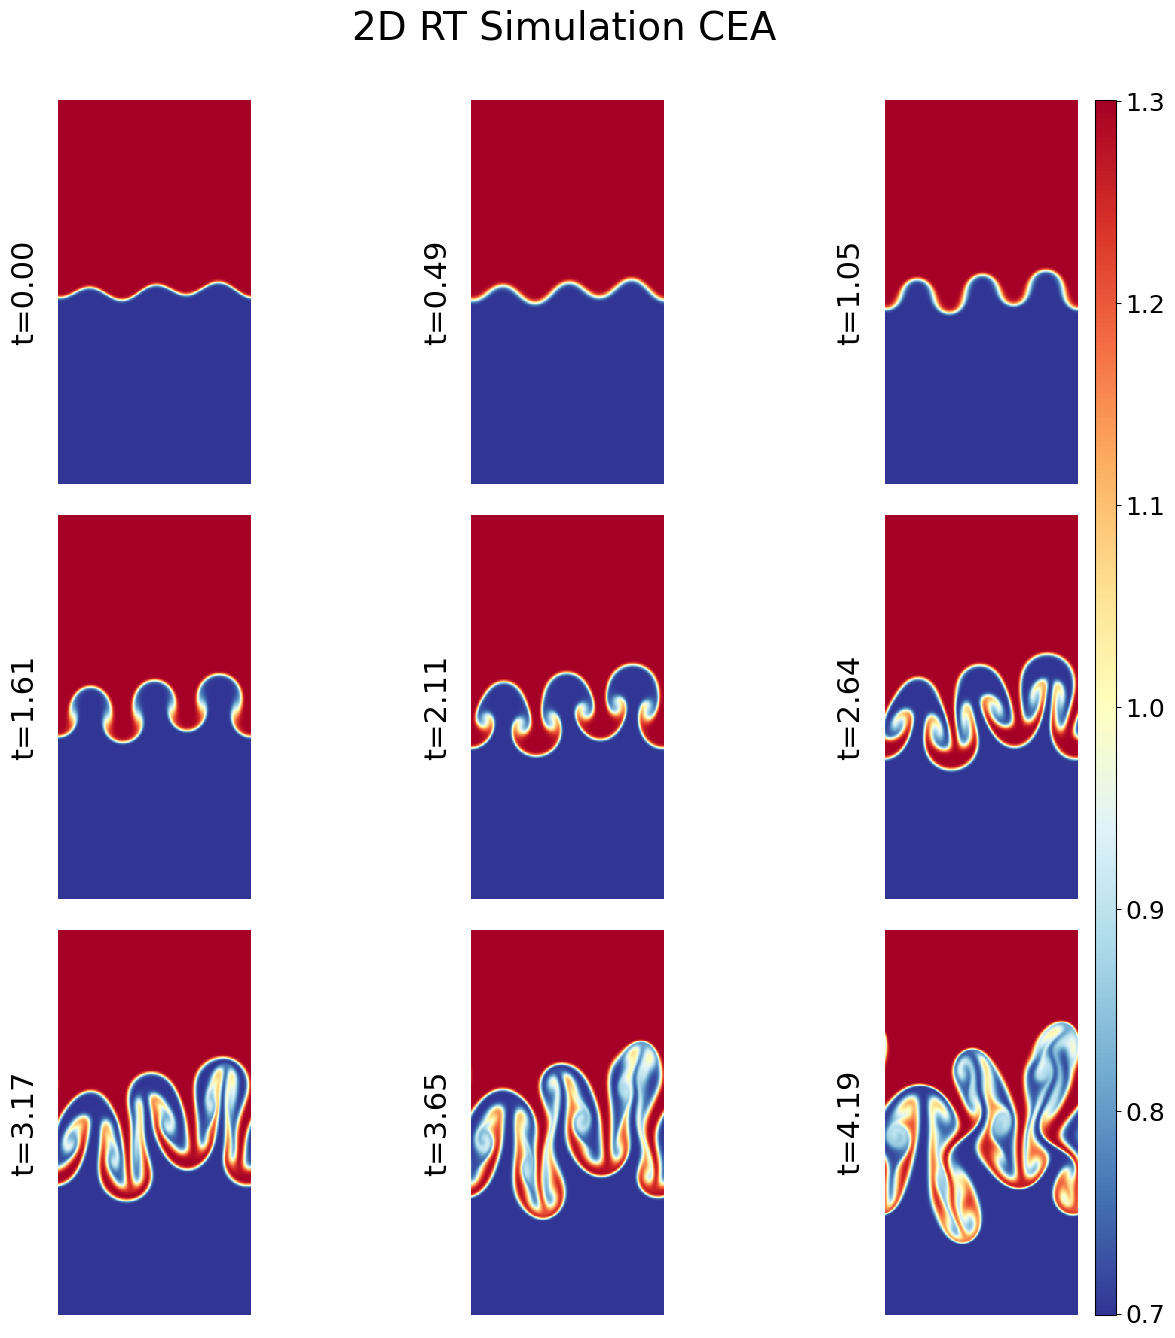

In [13]:
plot_sim_2d(
    sim,
    time,
    titre="2D RT Simulation CEA",
    save=True,
    path="../doc/BDRPReportTemplate/figures/intro/RTCEA_simulation_2D.png",
    text_fontsize=22,
    title_fontsize=28,
    colorbar_tick_fontsize=18,
    shared_colorbar=True,
)

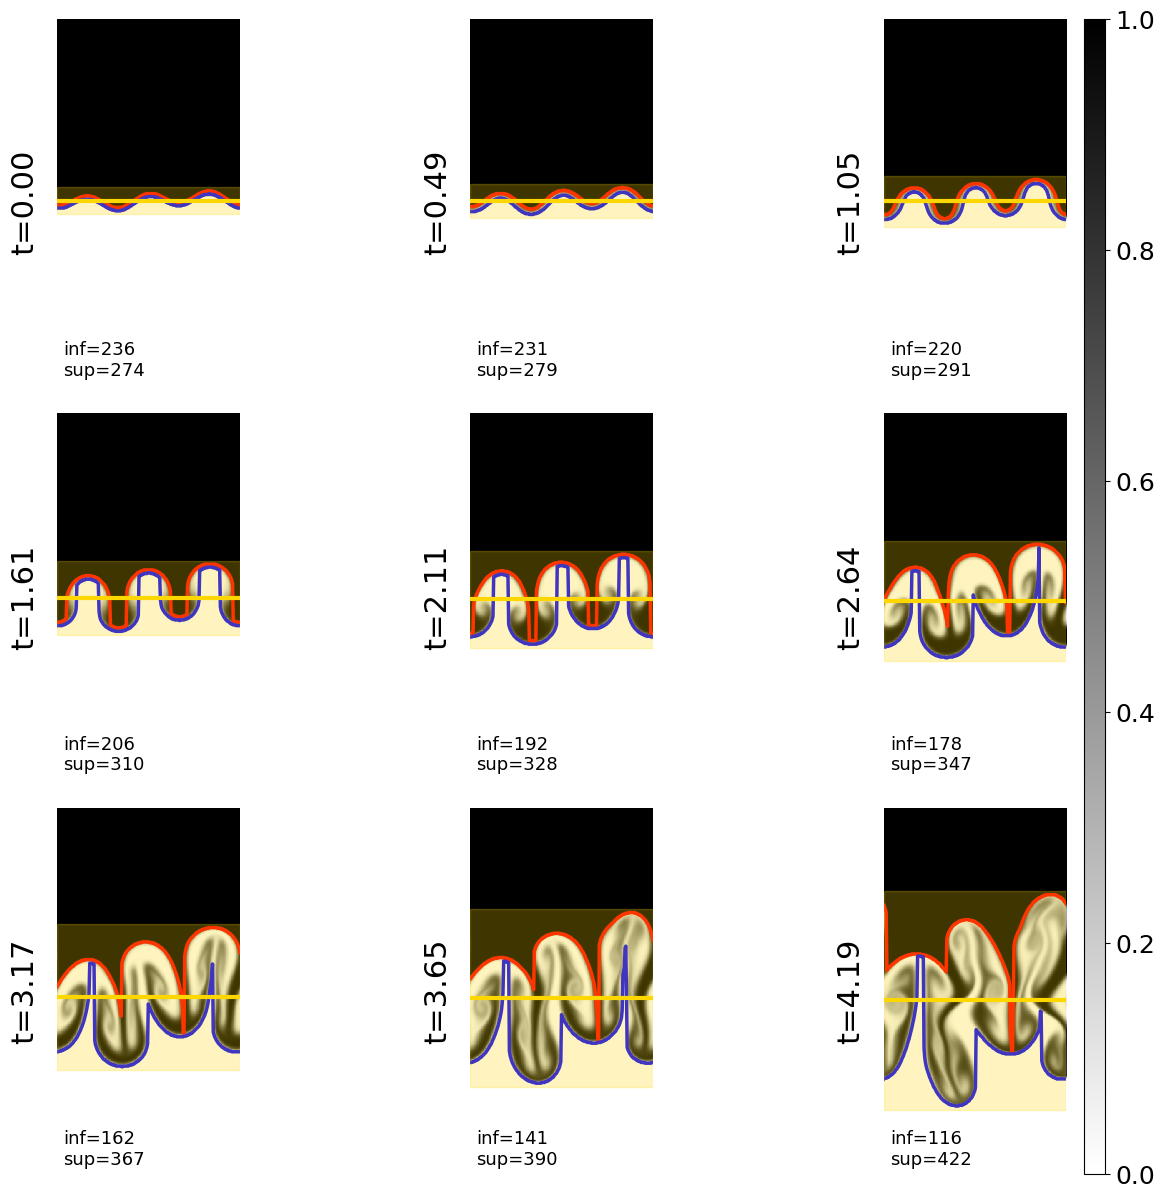

In [17]:
def plot_sim_2d_melange_info(sim, alpha_band=0.25, epsilon=0.5, marge=10):
    """
    Affiche une série de simulations 2D à différents instants, avec les bornes
    de mélange tracées colonne par colonne.

    Args:
        sim (ndarray): simulations de forme (n, h, w)
        alpha_band (float): opacité de la bande verte
        epsilon (float): seuil utilisé pour calculer les bornes de la zone de mélange
        marge (int): marge en pixels ajoutée aux bornes
    """
    time_fontsize = 22
    bounds_fontsize = 13
    colorbar_tick_fontsize = 18
    bound_linewidth = 2.5
    middle_linewidth = 3.0

    fig = plt.figure(figsize=(15, 15))
    gs = fig.add_gridspec(3, 3, wspace=0.35, hspace=0.08)
    fig.subplots_adjust(right=0.88)

    indices = [i * sim.shape[0] // 9 for i in range(9)]
    vmin = np.nanmin(sim[indices, :, :])
    vmax = np.nanmax(sim[indices, :, :])
    axes = []
    imgplot = None

    for i, nb in enumerate(indices):
        img = sim[nb]
        row, col = divmod(i, 3)
        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)
        imgplot = ax.imshow(
            img,
            interpolation='nearest',
            cmap='binary',
            vmin=vmin,
            vmax=vmax
        )
        ax.axis('off')
        ax.text(
            -0.1,
            0.5,
            f"t={time[nb]:.2f}",
            transform=ax.transAxes,
            rotation=90,
            va='center',
            ha='right',
            fontsize=time_fontsize,
            color='black'
        )
        h, _ = img.shape
        borne_inf, borne_sup, borne_inf_col, borne_sup_col = taille_zone_melange(
            img,
            epsilon=epsilon,
            marge=marge,
            list=True
        )

        if borne_inf is None or borne_sup is None:
            continue

        cols = np.arange(img.shape[1])
        valid_inf = ~np.isnan(borne_inf_col)
        valid_sup = ~np.isnan(borne_sup_col)

        if np.any(valid_inf):
            ax.plot(cols[valid_inf], borne_inf_col[valid_inf], color='red', linewidth=bound_linewidth, label='borne inf')
        if np.any(valid_sup):
            ax.plot(cols[valid_sup], borne_sup_col[valid_sup], color='blue', linewidth=bound_linewidth, label='borne sup')

        ax.axhspan(
            borne_inf,
            borne_sup,
            xmin=0,
            xmax=1,
            facecolor='gold',
            edgecolor='gold',
            linewidth=1.0,
            alpha=alpha_band,
            zorder=10
        )

        milieu_zone_melange = (borne_inf + borne_sup) // 2
        # ax.axhline(y=h // 2, color='white', linewidth=2)
        ax.axhline(y=milieu_zone_melange, color='gold', linewidth=middle_linewidth)
        ax.text(
            8,
            h - 8,
            f"inf={borne_inf}\nsup={borne_sup}",
            ha='left',
            va='bottom',
            fontsize=bounds_fontsize,
            color='black',
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5}
        )

    right_axes = axes[2::3]
    right_edge = max(ax.get_position().x1 for ax in right_axes)
    bottom = min(ax.get_position().y0 for ax in axes)
    top = max(ax.get_position().y1 for ax in axes)
    colorbar_pad = 0.012
    colorbar_width = 0.014
    cax = fig.add_axes([right_edge + colorbar_pad, bottom, colorbar_width, top - bottom])
    cbar = fig.colorbar(imgplot, cax=cax)
    cbar.ax.tick_params(labelsize=colorbar_tick_fontsize)

    plt.savefig(
        "../doc/BDRPReportTemplate/figures/ch3/zone_melange.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
    


sim = normalize2d(sim)
plot_sim_2d_melange_info(sim, alpha_band=0.25, epsilon=0.1, marge=5)

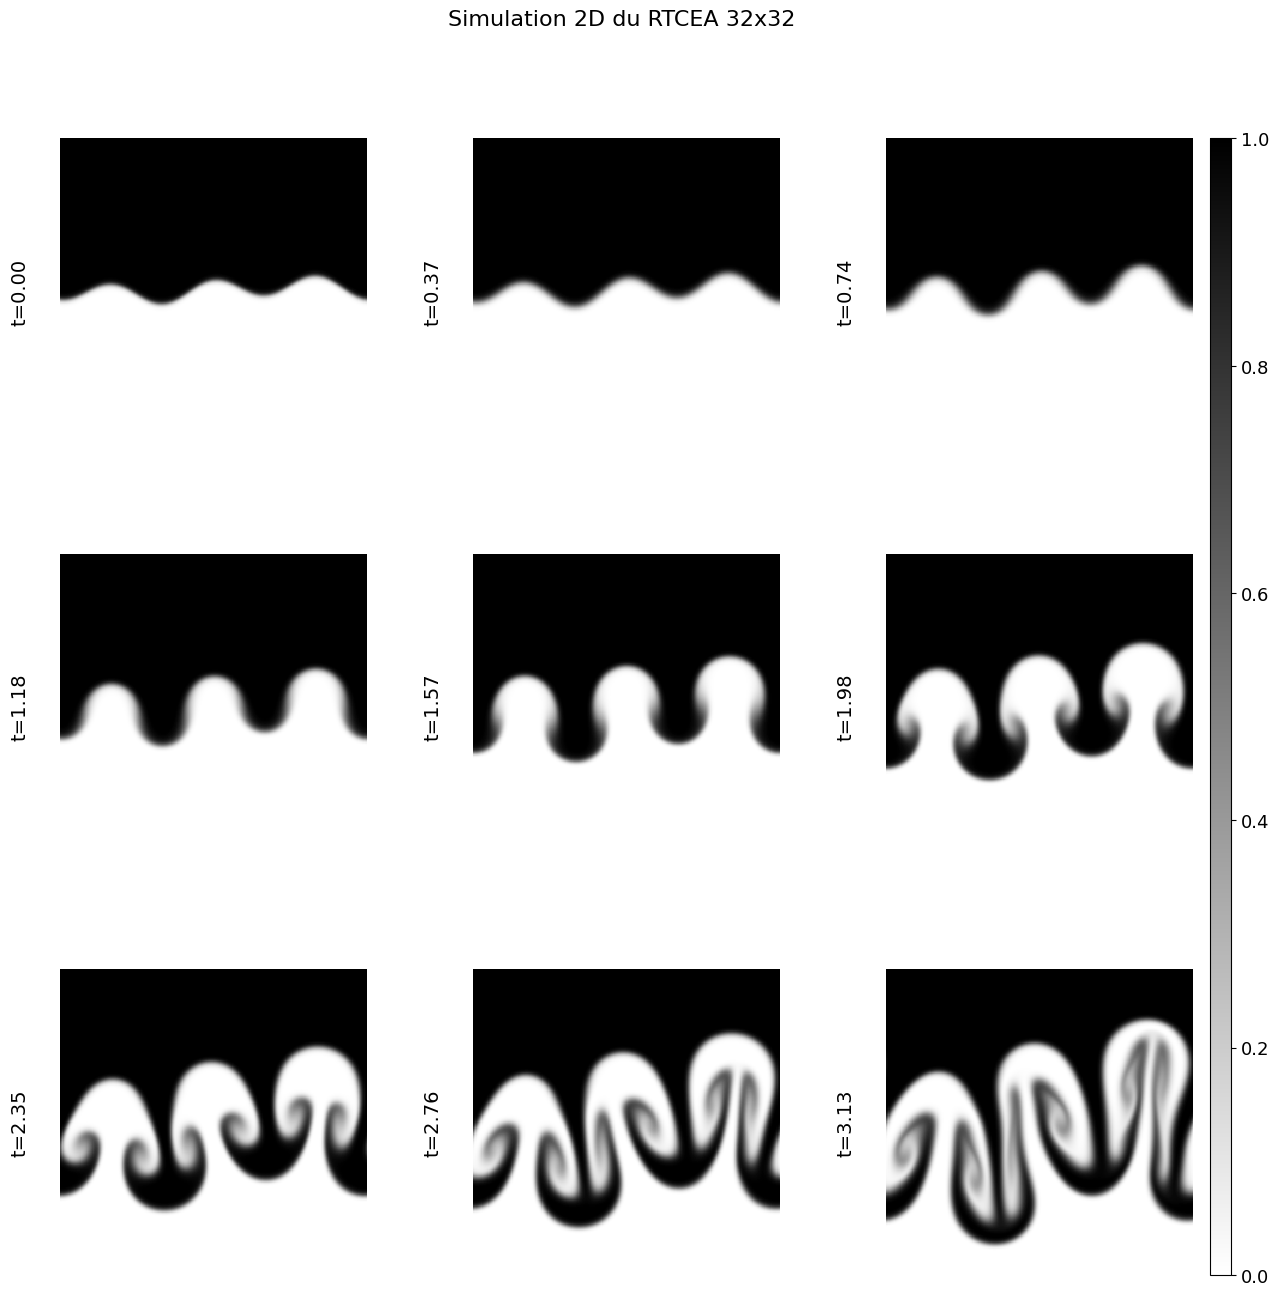

In [15]:
sim_norm, new_time = data_preprocessing(sim, time, resize=256)
plot_sim_2d(
    sim_norm, 
    new_time, 
    titre="Simulation 2D du RTCEA 32x32", 
    save=True,
    path="../doc/BDRPReportTemplate/figures/ch1/RTI.png",
    cmap='binary',
    shared_colorbar=True
)

In [16]:
# # Deformation de la zone de mélange

# data_norm = data_normalise_2d(data, labels, marge=0.15, square=True)
# atwood = create_atwood_dic(labels)

# idxs = atwood[0.3]
# sim2 = data_norm[idxs,:,:] 
# time2 = labels[idxs,1]

# plot_sim_2d(sim2, time2)
# print(sim2.shape)